In [ ]:
#!git clone https://github.com/whyhardt/SPICE.git

In [ ]:
# !pip install -e SPICE

In [1]:
import sys

import torch

from spice import SpiceEstimator

sys.path.append("../../..")
from weinhardt2026.utils.benchmarking_gru import GRUModel, training
from weinhardt2026.studies.castro2025.benchmarking_castro2025 import Castro2025Model, get_dataset, generate_behavior
import spice_castro2025

## Load dataset

In [2]:
path_data = 'data/eckstein2024.csv'
test_sessions = (2,)  # pick sessions that exist for all participants; adjust if needed
dataset_train, dataset_test, info_dataset = get_dataset(path_data=path_data, test_sessions=test_sessions, verbose=True)

Shape of dataset: torch.Size([4158, 150, 1, 13])
Number of participants: 862
Number of actions in dataset: 4


In [3]:
# keep only 100 participants for rapid prototyping
from spice import SpiceDataset

keep_participants = torch.arange(0, 100)

def keep_subset(dataset, subset):
    participant_ids = dataset.xs[:, 0, 0, -1]
    mask = torch.isin(participant_ids, subset)
    return SpiceDataset(dataset.xs[mask], dataset.ys[mask])

dataset_train = keep_subset(dataset_train, keep_participants)
dataset_test = keep_subset(dataset_test, keep_participants)    

print(f"Shape of dataset: {dataset_train.xs.shape}")
print(f"Number of participants: {dataset_train.n_participants}")
print(f"Number of actions in dataset: {dataset_train.n_actions}")

Shape of dataset: torch.Size([384, 150, 1, 13])
Number of participants: 100
Number of actions in dataset: 4


## SPICE Setup

## SPICE Training

Let's setup now the `SpiceEstimator` object and fit it to the data! 

We are going to do this in two steps:

1. Without fitting the SINDy coefficients to get the pure RNN performance given the selected architecture. 
2. With fitting SINDy coefficients to get the final performance of the interpretable model

That way we can disentangle the gap between GRU and SPICE w.r.t. architecture and SINDy library 

In [14]:
# fitting without SINDy coefficients
path_spice = 'params/spice_castro2025.pkl'

estimator = SpiceEstimator(
        # model paramaeters
        spice_class=spice_castro2025.SpiceModel,
        spice_config=spice_castro2025.CONFIG,
        n_actions=dataset_train.n_actions,
        n_participants=dataset_train.n_participants,
        
        epochs=1000,
        
        sindy_weight=0,
        sindy_library_polynomial_degree=2,
        sindy_pruning_frequency=100,
        sindy_ensemble_pruning=0.05,
        sindy_threshold_pruning=0.01,
        sindy_alpha=0.0001,
        
        save_path_spice=path_spice,
        verbose=True,
    )
estimator.fit(dataset_train.xs, dataset_train.ys, dataset_test.xs, dataset_test.ys)

100%|██████████████████████████████████████████████████████████████| 1000/1000 [33:03<00:00,  1.98s/it, L(Train)=0.4130846, L(Val,RNN)=0.4484034, Conv=6.55e-03]
Maximum number of training epochs reached.
Model did not converge yet.

Stage 2: SINDy refit


100%|██████████| 1000/1000 [01:43<00:00,  9.69it/s, loss=0.0296574, n_params=36.79+/-0.46]



Training results:
	L(Train, RNN): 0.4130846
	L(Val, RNN):   0.4484034

RNN training finished.
Training took 2087.85 seconds.
Saving SPICE model to params/spice_castro2025.pkl...


In [4]:
path_spice = 'params/spice_castro2025.pkl'

estimator = SpiceEstimator(
        # model paramaeters
        spice_class=spice_castro2025.SpiceModel,
        spice_config=spice_castro2025.CONFIG,
        n_actions=dataset_train.n_actions,
        n_participants=dataset_train.n_participants,
        
        epochs=1000,
        warmup_steps=200,
        learning_rate=0.01,
        ensemble_size=10,
        
        sindy_weight=0.1,
        sindy_alpha=0.0001,
        sindy_pruning_frequency=100,
        sindy_threshold_pruning=0.01,
        sindy_ensemble_pruning=0.05,
        sindy_library_polynomial_degree=2,
        
        verbose=True,
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
        save_path_spice=path_spice,
    )

In [ ]:
estimator.fit(dataset_train.xs, dataset_train.ys, dataset_test.xs, dataset_test.ys)

In [ ]:
estimator.load_spice(path_spice)
estimator.aggregate_coefficients()

In [ ]:
# Print example SPICE model for first participant
print("\nExample SPICE model (participant 0):")
estimator.print_spice_model(participant_id=3)

## Benchmarking

### Castro2025 benchmark model

In [6]:
# Benchmark model: Castro et al. 2025
cfs = Castro2025Model(
    n_participants=dataset_train.n_participants,
    n_actions=dataset_train.n_actions,
    batch_first=True,
    )

path_cfs = path_spice.replace('spice_', 'cfs_')

In [ ]:
optimizer_cfs = torch.optim.Adam(params=cfs.parameters(), lr=0.01)
epochs = 1000

cfs = training(
    model=cfs,
    optimizer=optimizer_cfs,
    dataset_train=dataset_train,
    dataset_test=dataset_test,
    epochs=epochs,
)

torch.save(cfs.state_dict(), path_cfs)

In [ ]:
cfs.load_state_dict(torch.load(path_cfs, map_location='cpu'))

### GRU Model

In [ ]:
gru = GRUModel(
    n_actions=dataset_train.n_actions, 
    # additional_inputs=2, 
    dropout=0.1,
    hidden_size=32,
    )
path_gru = path_spice.replace('spice_', 'gru_')

In [ ]:
epochs = 1000
optimizer_gru = torch.optim.Adam(gru.parameters(), lr=0.01)

gru = training(
    model=gru,
    optimizer=optimizer_gru,
    dataset_train=dataset_train,
    dataset_test=dataset_test,
    epochs=epochs,
    ).to(torch.device('cpu'))

torch.save(gru.state_dict(), path_gru)

In [ ]:
gru.load_state_dict(torch.load(path_gru, map_location='cpu'))

# ANALYSIS

In [10]:
from weinhardt2026.analysis.analysis_model_evaluation import analysis_model_evaluation
from weinhardt2026.analysis.analysis_coefficients_distributions import analysis_coefficients_distributions
from weinhardt2026.analysis.analysis_coefficients_individuals import analysis_coefficients_individuals
from weinhardt2026.analysis.analysis_value_trajectories import plot_value_trajectories, plot_value_trajectories_multi
from analysis_generative import analysis_generative_behavior

## Analysis Model Evaluation

In [17]:
analysis_model_evaluation(
    dataset=dataset_test,
    spice_model=estimator,
    benchmark_model=cfs.to(torch.device('cpu')),
    gru_model=gru.eval().to(torch.device('cpu')),
    )

Computing choice probabilities with benchmark model...
Computing choice probabilities with GRU model...
Computing choice probabilities with SPICE model...


,Trial Lik.,(std),n_parameters,(std),NLL,AIC,BIC
Benchmark,0.634490,0.163233,13.000000,0.000000,6757.135742,13540.271484,13639.148438
GRU,0.619664,0.167181,6852.000000,0.000000,7108.311523,27920.623047,80036.640625
SPICE-RNN,0.638647,0.164512,10221.000000,0.000000,6660.135742,33762.273438,111502.757812
SPICE,0.018705,0.268932,36.790001,0.456048,59099.773438,118273.125000,118552.953125


## Analysis Value Trajectories

Plot saved to: results


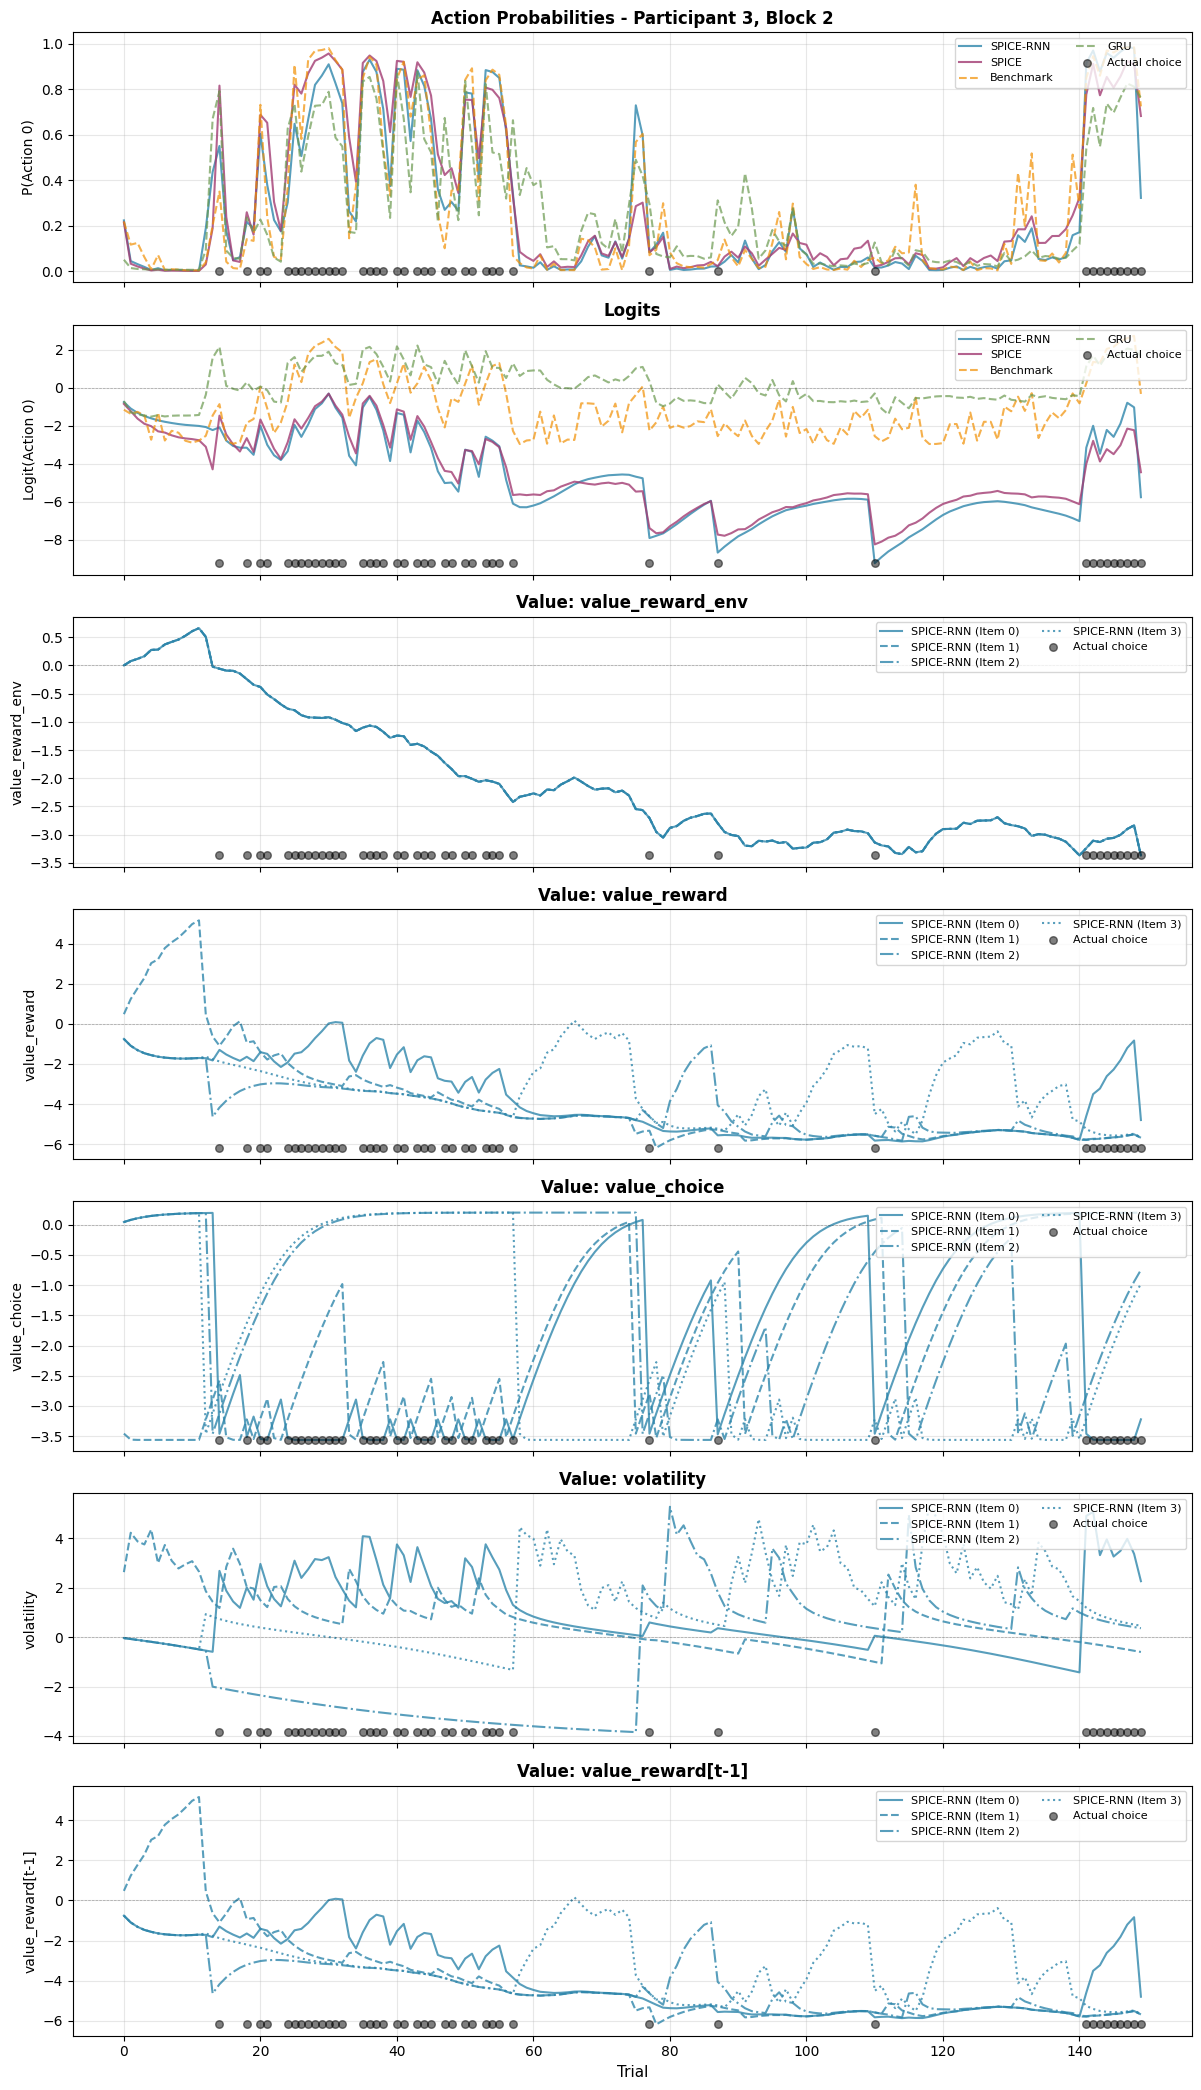

In [18]:
fig = plot_value_trajectories(
    dataset=dataset_test,
 
    action_idx=0,
    participant_id=3,
    block_id=2,

    spice_model=estimator,
    benchmark_model=cfs,
    gru_model=gru,

    output_path='results',
)

## Analysis coefficient distributions

In [ ]:
analysis_coefficients_distributions(
    spice_model=estimator,
    output_dir='results',
)

## Analysis Individual Differences

In [ ]:
# analysis_coefficients_individuals(
#     criterion="SomeCriterionColumnInYourDataset",
#     analysis="disc",  # also: "cont"
#     reference="ReferenceGroupFromCriterionColumn",  # only necessary if analysis="disc"
    
#     path_data=path_file,
    
#     spice_model=estimator,
    
#     dir_output='results',
# )

## Generative Behavior Analysis

In [ ]:
estimator.eval()
generate_behavior(
    model=estimator,
    dataset=dataset_train,
    save_dataset='data/eckstein2024_spice.csv'
)

estimator.use_sindy(False)
generate_behavior(
    model=estimator,
    dataset=dataset_train,
    save_dataset='data/eckstein2024_spice_rnn.csv'
)

gru.eval()
generate_behavior(
    model=gru,
    dataset=dataset_train,
    save_dataset='data/eckstein2024_gru.csv'
)

generate_behavior(
    model=cfs,
    dataset=dataset_train,
    save_dataset='data/eckstein2024_cfs.csv'
)

In [ ]:
analysis_generative_behavior(
    path_data_real=path_data,
    path_data_gru='data/eckstein2024_gru.csv',
    path_data_benchmark='data/eckstein2024_cfs.csv',
    path_data_spice='data/eckstein2024_spice.csv',
    path_data_spice_rnn='data/eckstein2024_spice_rnn.csv',
    output_dir='results',
)